In [1]:
from huggingface_hub import login as hf_login

from dotenv import load_dotenv
import json
from tqdm import tqdm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from datasets import DatasetDict, Dataset
from transformers import AutoTokenizer

import sys; sys.path.insert(0, '..')
from datatypes.resume_data_type import Resume # type: ignore
from utils.constants import Constants # type: ignore
from utils.utility import Utility # type: ignore
from utils.resume_util import ResumeUtil # type: ignore
from utils.resume_model import ResumeModel # type: ignore
from utils.ollama_util import Ollama # type: ignore
from concurrent.futures import ThreadPoolExecutor


## Login to hub

In [2]:
load_dotenv(override=True)
hf_login()

## Loading the Dataset
Dataset is created using Claude Opus by feeding in the extracted text from resumes to generate a structured JSON.

In [3]:
path_to_dataset = "../datasets/resume_to_json_1.csv"

In [4]:
df = pd.read_csv(path_to_dataset)
df.head()

,resume_text,structured_json
0,"Sawarni Swaroop\nBangalore, India\nm sawarnisw...","{""description"":""Results-driven Software Develo..."
1,Siddharth Mishra\nStaff Cloud Engineer\nContac...,"{""description"":""Staff Cloud Engineer with 14+ ..."
2,Jun Kumar\nFirmware Engineer\n0151 4722592 ju...,"{""description"":""Firmware Engineer with 3+ year..."
3,James King\nMobile Developer\n+918626791083 j...,"{""description"":""Mobile Developer with 4+ years..."
4,Sofia Schmidt\nSr. Cybersecurity Engineer\nCon...,"{""description"":"""",""education"":[{""school_name"":..."


In [5]:
sample_idx = 6

In [6]:
print(df['resume_text'].iloc[sample_idx])

Yan Rajan
Jr. Research Data Scientist
+91-7183239375  yanrajan@protonmail.com  Chennai, India  linkedin.com/in/yan-rajan  github.com/yanrajan39
CAREER SUMMARY
Experienced Research Data Scientist skilled in pandas, SQL, and Airflow, with 2+ years delivering predictive models and
data-driven products. Adept at performance optimization, translating ambiguous requirements into reliable, scalable
systems, and driving measurable business impact.
PROFESSIONAL EXPERIENCE
Applied Data Scientist, Wavelengthlabs Technologies
12/2024 to 05/2026
Pune, India
 Partnered with engineering to move models from notebooks to production, reducing scoring latency to under
50ms.
 Reduced forecasting error (MAPE) by 25% using gradient-boosted models and richer feature engineering on A/B
Testing.
 Productionized the recommendation engine that increased click-through rate by 40% and session depth by 98%.
 Built an A/B-testing platform with CUPED and sequential testing, enabling 4+ concurrent experiments and 3x
e

In [7]:
sample_json = json.loads(df['structured_json'].iloc[sample_idx])
print(json.dumps(sample_json, indent=4))

{
    "description": "Experienced Research Data Scientist skilled in pandas, SQL, and Airflow, with 2+ years delivering predictive models and data-driven products. Adept at performance optimization, translating ambiguous requirements into reliable, scalable systems, and driving measurable business impact.",
    "education": [
        {
            "school_name": "Glenmore College of Engineering",
            "year": "2020",
            "degree": "Ph.D. in Artificial Intelligence"
        },
        {
            "school_name": "Meridian Institute of Technology",
            "year": "2018",
            "degree": "M.Tech in Data Analytics"
        },
        {
            "school_name": "Eastvale Institute of Science and Technology",
            "year": "2016",
            "degree": "B.Tech in Information Technology"
        }
    ],
    "skills": [
        "Python",
        "R",
        "SQL",
        "Scala",
        "scikit-learn",
        "XGBoost",
        "TensorFlow",
        "PyT

In [8]:
resume_texts = [text for text in df["resume_text"]]

## Data Analysis

In [9]:
tokenizer = AutoTokenizer.from_pretrained(Constants.EXTRACTION_BASE_MODEL_NAME)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   resume_text      601 non-null    str  
 1   structured_json  601 non-null    str  
dtypes: str(2)
memory usage: 3.1 MB


In [11]:
# Checking if all the resume jsons are in correct shape...
resume_jsons = [Resume.model_validate_json(resume_json) for resume_json in df["structured_json"]]
print(f"All resumes are valid: {all(resume_jsons)}")

All resumes are valid: True


In [12]:
# Checking for how many inferred texts (from the resume json) are not found in the resume text...
all_inferred_texts = []
for idx, (resume, text) in enumerate(zip(resume_jsons, resume_texts)):
    inferred_texts = ResumeUtil.get_inferred_texts_from_resume(resume, text)
    all_inferred_texts.extend([{"index": idx, "text_from_json": value} for value in inferred_texts])

print(f"Total inferred (not found in resume text): {len(all_inferred_texts)}")
for item in all_inferred_texts:
    print(item)

Total inferred (not found in resume text): 0


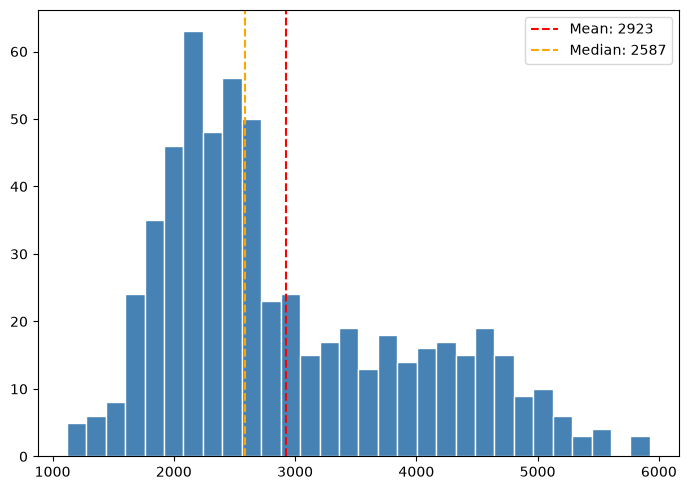

Min:      1118
Max:      5926
Mean:     2923
Median:   2587
Std:      1030


In [13]:
# Checking the number of characters in each resume texts...
resume_lengths = [len(resume_text) for resume_text in df["resume_text"]]
ResumeUtil.plot_resume_data(resume_lengths)

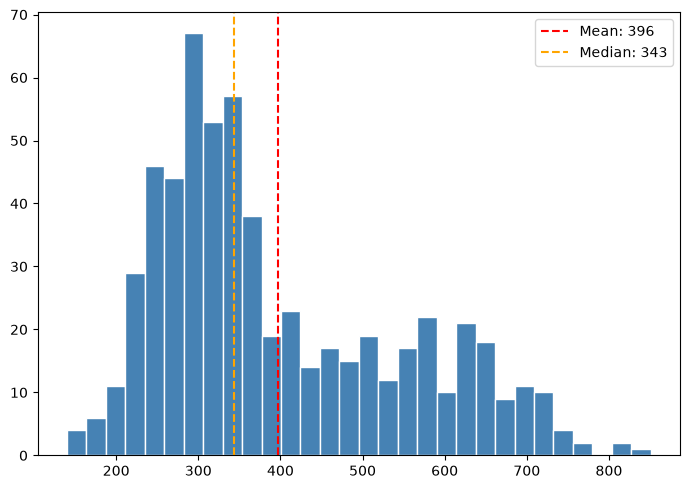

Min:       140
Max:       851
Mean:      396
Median:    343
Std:       149


In [14]:
# Checking the max number of words in each resume texts...
resume_word_counts = [len(text.split()) for text in df["resume_text"]]
ResumeUtil.plot_resume_data(resume_word_counts)

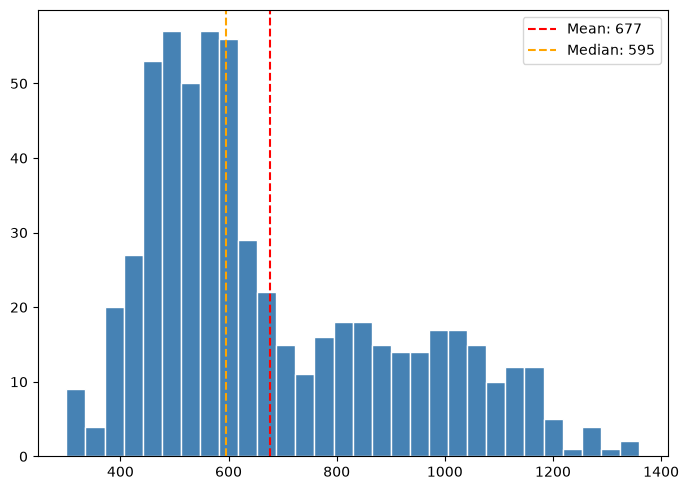

Min:       300
Max:      1359
Mean:      677
Median:    595
Std:       232


In [15]:
# Checking the max number of tokens in all the resume_text using the tokenizer from the resume scoring model...
resume_text_token_lengths = [len(tokenizer.encode(text)) for text in df["resume_text"]]
ResumeUtil.plot_resume_data(resume_text_token_lengths)

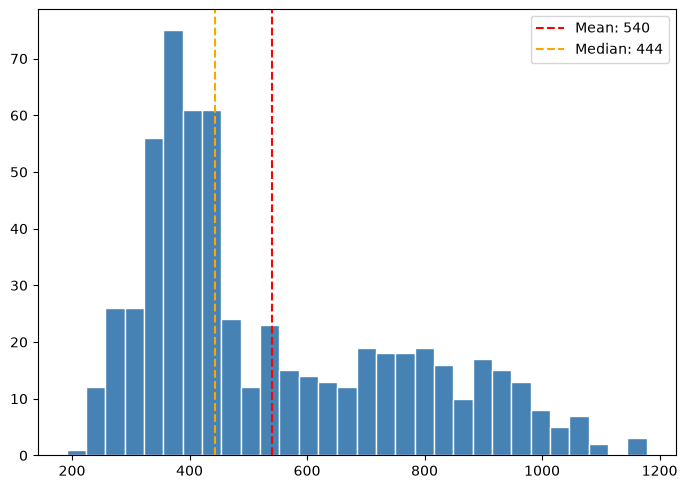

Min:       191
Max:      1178
Mean:      540
Median:    444
Std:       224


In [16]:
# Checking the max number of tokens in all the structured_json using the tokenizer from the resume scoring model...
structured_json_token_lengths = [len(tokenizer.encode(text)) for text in df["structured_json"]]
ResumeUtil.plot_resume_data(structured_json_token_lengths)

In [17]:
# Checking the length of tokens in system prompt
print(f"Length of system prompt: {len(tokenizer.encode(Constants.EXTRACTION_SYSTEM_PROMPT_TEMPLATE))} tokens")

Length of system prompt: 266 tokens


In [18]:
# Checking the length of tokens in user prompt
print(f"Length of user prompt: {len(tokenizer.encode(Constants.EXTRACTION_USER_PROMPT_TEMPLATE))} tokens")

Length of user prompt: 15 tokens


#### Analysis results:
- Total number of rows: 600
- Total number of JSONs which are not proper: 0
- Total inferred (not found in resume text): 0
- Maximum characters in resume_text: 5926
- Maximum words in resume_text: 851
- Maximum token size in resume_text: 1359
- Maximum token size in structured_json: 1178
- Number of tokens in system prompt: 261
- Number of tokens in user prompt: 15


## Creating train, validation and test datasets from the original dataset

In [19]:
model = ResumeModel(Constants.EXTRACTION_FT_OLLAMA_ENDPOINT)

In [20]:
def make_message(row):
    return model.make_prompt_with_assistant(row["resume_text"], row["structured_json"])

In [21]:
df["messages"] = df.apply(make_message, axis=1)
final_df = df[['messages']]
final_df

,messages
0,"[{'role': 'system', 'content': 'You are a resu..."
1,"[{'role': 'system', 'content': 'You are a resu..."
2,"[{'role': 'system', 'content': 'You are a resu..."
3,"[{'role': 'system', 'content': 'You are a resu..."
4,"[{'role': 'system', 'content': 'You are a resu..."
...,...
596,"[{'role': 'system', 'content': 'You are a resu..."
597,"[{'role': 'system', 'content': 'You are a resu..."
598,"[{'role': 'system', 'content': 'You are a resu..."
599,"[{'role': 'system', 'content': 'You are a resu..."


In [22]:
train_df, temp_df = train_test_split(final_df, random_state=42, test_size=0.2)
train_df.info()

<class 'pandas.DataFrame'>
Index: 480 entries, 9 to 102
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   messages  480 non-null    object
dtypes: object(1)
memory usage: 7.5+ KB


In [23]:
valid_df, test_df = train_test_split(temp_df, random_state=42, train_size=0.5)
valid_df.info()

<class 'pandas.DataFrame'>
Index: 60 entries, 135 to 538
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   messages  60 non-null     object
dtypes: object(1)
memory usage: 960.0+ bytes


## Saving dataset as hugging face dataset

In [24]:
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(valid_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False)
})
dataset

DatasetDict({
    train: Dataset({
        features: ['messages'],
        num_rows: 480
    })
    validation: Dataset({
        features: ['messages'],
        num_rows: 60
    })
    test: Dataset({
        features: ['messages'],
        num_rows: 61
    })
})

In [25]:
# Save dataset in huggingface hub
# dataset.push_to_hub(Constants.EXTRACTION_DATASET_NAME)

## Training

#### Training is done on Kaggle
[Link](https://www.kaggle.com/code/sawarni99/resume-extraction-training-unsloth) to the colab and the model is pushed to hub.

- Base model used for finetuning: Llama-3.2-3B-Instruct
- Used unsloth FastLanguageModel for fine tuning.
- Used quantization of 4-bit with 16 rank LoRA adapter on attention layers.

Training Loss: 0.2576
<br>
Validation Loss: 0.2721
<br>
Training reports: [wandb](https://wandb.ai/sawarni/huggingface/runs/lkzdoyuk?nw=nwusersawarni99)

## Inference

In [26]:
# Ollama(Constants.EXTRACTION_FT_OLLAMA_ENDPOINT).delete()

In [ ]:
my_resume_text = ResumeUtil.extract_text(file_path="/Users/mayur/Documents/My Resume/SawarniSwaroop.pdf")
response = model.generate(my_resume_text)

In [37]:
my_resume = ResumeUtil.create(response)
ResumeUtil.format(my_resume)

{
    "description": "Results-driven Software Developer with 3+ years of experience in Spring boot, React JS, and SQL, specializing in performance optimization and cybersecurity. Skilled in solving complex problems and leading projects to success. Looking to leverage my technical expertise to drive innovation and deliver impactful software solutions in a dynamic environment.",
    "education": [
        {
            "school_name": "Karunya Institute of Technology and Science",
            "year": "2017",
            "degree": "Bachelor of Technology in Computer Science"
        }
    ],
    "skills": [
        "Java",
        "JavaScript",
        "SQL",
        "HTML",
        "CSS",
        "SpringBoot",
        "React.js",
        "Node.js",
        "SQL"
    ],
    "experience": [
        {
            "company_name": "Zoho Corp Pvt Ltd.",
            "start_year": "2021",
            "end_year": "Present",
            "descriptions": [
                "Introduced URL Monitoring f

## Evaluation

Doing inference on 61 tests by splitting them in batch of 10 so that it can run in local smoothly.

In [29]:
tests = dataset["test"]
tests

Dataset({
    features: ['messages'],
    num_rows: 61
})

In [30]:
def infer_and_evaluate(min, max, output_file):
    sample_test = tests.select(range(min, max))
    responses = []
    
    for test in tqdm(sample_test):
        messages = test["messages"]
        prediction = model.generate(messages[0:2])
        reference = messages[2]["content"]
        responses.append({
            "prediction": prediction,
            "reference": reference
        })

    predictions = [obj["prediction"] for obj in responses]
    references = [obj["reference"] for obj in responses]

    return model.evaluate(predictions=predictions, references=references, output_file=output_file)



In [ ]:
# infer_and_evaluate(10, 20, output_file='../evals/resume_extraction/resume_extraction_test_10_20.json')
# infer_and_evaluate(20, 30, output_file='../evals/resume_extraction/resume_extraction_test_20_30.json')
# infer_and_evaluate(30, 40, output_file='../evals/resume_extraction/resume_extraction_test_30_40.json')
# infer_and_evaluate(50, 60, output_file='../evals/resume_extraction/resume_extraction_test_50_60.json')

100%|██████████| 10/10 [01:46<00:00, 10.69s/it]


{'total_tests': 10,
 'rouge': {'rouge1': np.float64(0.9591120290549693),
  'rouge2': np.float64(0.956178362425112),
  'rougeL': np.float64(0.9574196912995078),
  'rougeLsum': np.float64(0.9567166959736211)},
 'exact_match': {'exact_match': np.float64(0.4)},
 'valid_json': {'valid_json_count': 10,
  'valid_json_score': 1.0,
  'invalid_json_idx': []}}